Loading saved model...


Saving img1.avif to img1.avif
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


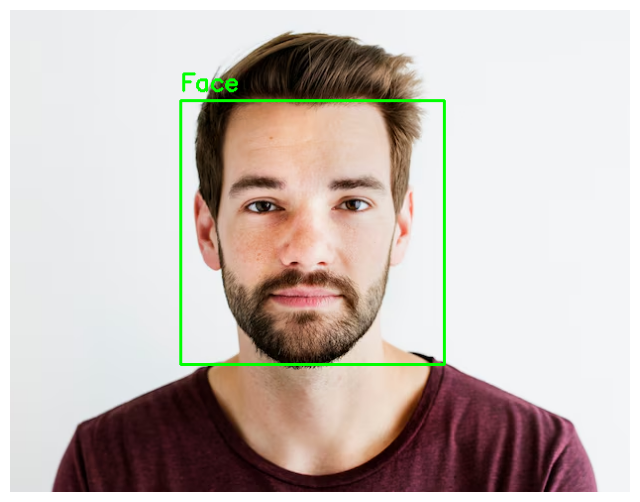

In [2]:
# -----------------------------
# Step 0: Install Libraries
# -----------------------------
!pip install kagglehub tensorflow opencv-python matplotlib

# -----------------------------
# Step 1: Import Libraries
# -----------------------------
import kagglehub
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
from google.colab import files

MODEL_PATH = "face_model.h5"

# -----------------------------
# Step 2: Check if Model Exists
# -----------------------------
if os.path.exists(MODEL_PATH):
    print("Loading saved model...")
    model = load_model(MODEL_PATH)

else:
    print("Training new model...")

    # -----------------------------
    # Step 3: Download Dataset
    # -----------------------------
    path = kagglehub.dataset_download("iamtushara/face-detection-dataset")
    print("Dataset path:", path)

    # -----------------------------
    # Step 4: Prepare Data
    # -----------------------------
    IMG_SIZE = 64
    data = []
    labels = []

    for root, dirs, files_list in os.walk(path):
        for file in files_list:
            if file.endswith(('.jpg', '.png', '.jpeg')):
                img_path = os.path.join(root, file)
                img = cv2.imread(img_path)

                if img is None:
                    continue

                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                data.append(img)
                labels.append(1)

    # Add non-face data (noise)
    for i in range(len(data)//2):
        noise = np.random.randint(0,255,(IMG_SIZE,IMG_SIZE,3),dtype=np.uint8)
        data.append(noise)
        labels.append(0)

    # Convert
    X = np.array(data) / 255.0
    y = np.array(labels)

    # Shuffle
    idx = np.random.permutation(len(X))
    X, y = X[idx], y[idx]

    # Split
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    print("Training samples:", len(X_train))

    # -----------------------------
    # Step 5: Build Model
    # -----------------------------
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    model.summary()

    # -----------------------------
    # Step 6: Train Model
    # -----------------------------
    model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

    # -----------------------------
    # Step 7: Save Model
    # -----------------------------
    model.save(MODEL_PATH)
    print("Model saved!")

# -----------------------------
# Step 8: Upload Image
# -----------------------------
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# -----------------------------
# Step 9: Face Detection + CNN
# -----------------------------
img = cv2.imread(image_path)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

faces = face_cascade.detectMultiScale(img_gray, scaleFactor=1.1, minNeighbors=5)

for (x, y, w, h) in faces:
    face_crop = img[y:y+h, x:x+w]
    face_resized = cv2.resize(face_crop, (64,64)) / 255.0
    face_resized = np.expand_dims(face_resized, axis=0)

    prediction = model.predict(face_resized)

    if prediction > 0.5:
        color = (0,255,0)
        label = "Face"
    else:
        color = (0,0,255)
        label = "No Face"

    cv2.rectangle(img, (x,y), (x+w,y+h), color, 2)
    cv2.putText(img, label, (x,y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

# -----------------------------
# Step 10: Show Output
# -----------------------------
plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()